In [1]:
from glob import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np
from subspaceadonnx import SubspaceAD

In [2]:
NORMAL_IMG_DIR = "datasets/leather/train/good"
TARGET_IMG_DIR = "datasets/leather/test/glue"

In [3]:
model = SubspaceAD(
    "models/dinov3_vitb_middle7.onnx",#models/dinov3_vitb_middle7.onnx
    pca_ev=0.99,
    feature_l2_normalize=True,
    normalize_map=False,
    calibration_target=0.5,
)

In [4]:
normal_imgs = [cv2.imread(f) for f in glob(f"{NORMAL_IMG_DIR}/*.png")]
model.fit(normal_imgs)  # list[np.ndarray]

Extracting features: 100%|██████████| 245/245 [00:14<00:00, 16.54it/s]


Fitting PCA on 192080 patch tokens with feature dim 768.


Calibrating anomaly-map scale: 100%|██████████| 245/245 [00:00<00:00, 258.00it/s]

Anomaly-map scale calibrated: fit_max=0.0476473, scale=10.4938, scaled_max=0.5


In [ ]:
def visualize_anomaly_map(target_img, 
                          anomaly_map, 
                          image_score,
                          threshold=0.5):
    """
    target_img: BGR HWC
    anomaly_map: HW float32
    image_score: float
    threshold: float, anomaly_mapの閾値
    """
    plt.figure(figsize=(12, 4))
    fig, axs = plt.subplots(1, 4, figsize=(12, 4))
    axs[0].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Input Image")
    axs[1].imshow(anomaly_map, cmap="jet", vmin=0, vmax=1)
    axs[1].set_title(f"Anomaly Map (score={image_score:.2f})")
    axs[2].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
    axs[2].imshow(anomaly_map, cmap="jet", alpha=0.5, vmin=0, vmax=1)
    axs[2].set_title("Overlay")
    axs[3].imshow(anomaly_map > threshold, cmap="gray")
    axs[3].set_title(f"Thresholded (>{threshold})")
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


<Figure size 1200x400 with 0 Axes>

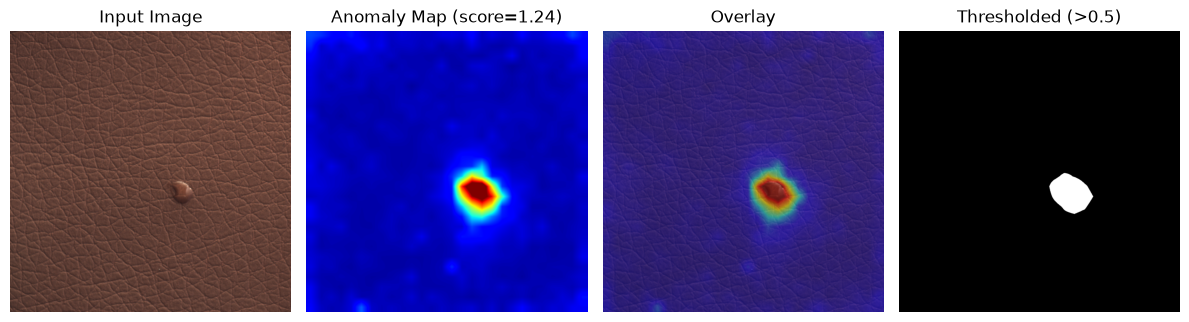

<Figure size 1200x400 with 0 Axes>

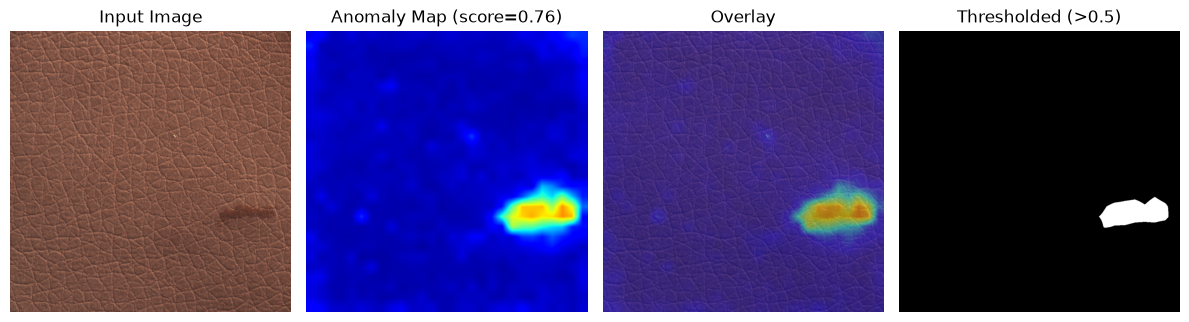

<Figure size 1200x400 with 0 Axes>

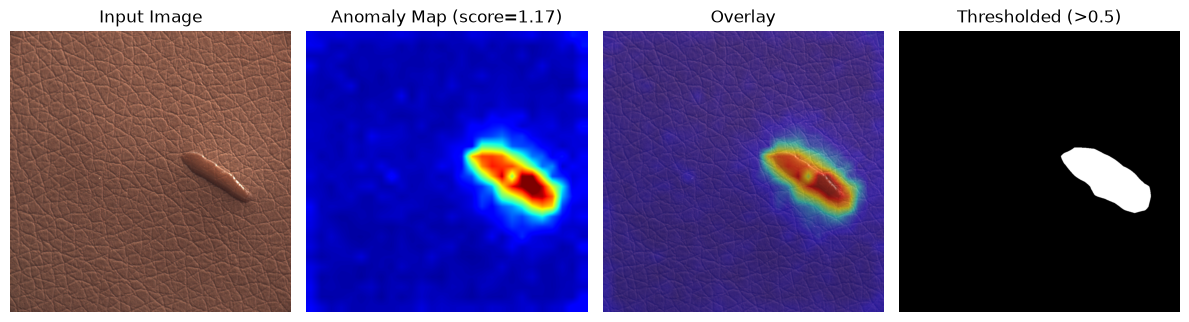

<Figure size 1200x400 with 0 Axes>

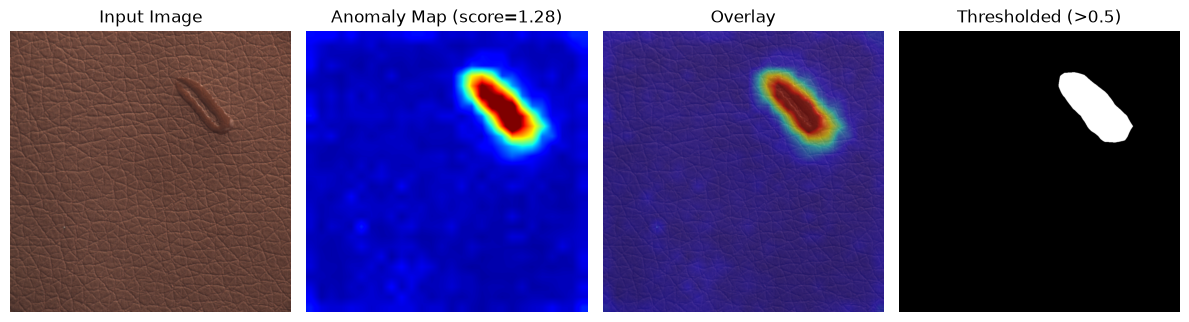

<Figure size 1200x400 with 0 Axes>

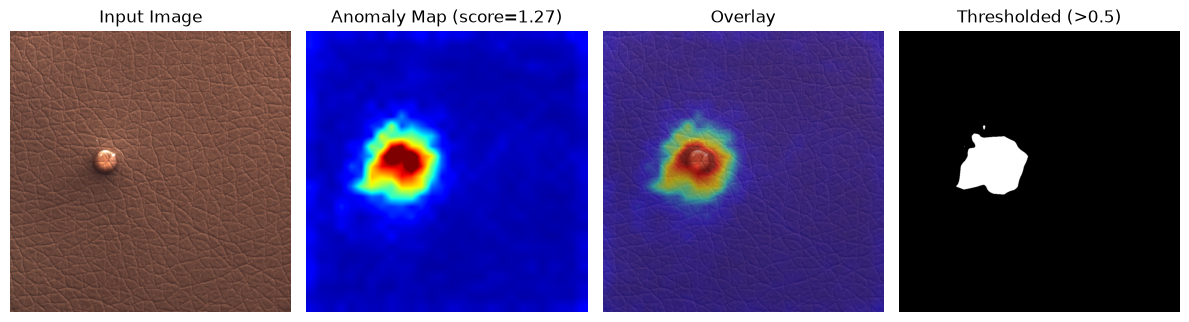

In [6]:
target_imgs = [cv2.imread(f) for f in glob(f"{TARGET_IMG_DIR}/*.png")]
for target_img in target_imgs[:5]:
    anomaly_map = model(target_img)
    image_score = model.image_score(target_img, method="max")
    visualize_anomaly_map(target_img, anomaly_map, image_score, threshold=0.5)

In [ ]:
# save PCA parameters to a file
pca_params = model.state_dict()
np.savez("models/pca_params.npz", **pca_params)

In [ ]:
# load PCA parameters from a file
model.load_state_dict(np.load("models/pca_params.npz", allow_pickle=True))

### Run evaluation

In [1]:
from subspaceadonnx import MVTecEvaluator

evaluator = MVTecEvaluator(
    dataset_root="datasets",
    dataset_names=["leather"],
    onnx_path="models/dinov3_vitb_middle7.onnx",
    providers=["WebGpuExecutionProvider"]
)
result = evaluator.evaluate()
for key, v in result.items():
    print(f"{key}: {v}")

[MVTec 1/1][leather] 訓練開始 (245枚)


/Users/satoshi/projects/python/SubspaceAD/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting features: 100%|██████████| 245/245 [00:14<00:00, 16.41it/s]


Fitting PCA on 192080 patch tokens with feature dim 768.


Calibrating anomaly-map scale: 100%|██████████| 245/245 [00:00<00:00, 258.55it/s]

Anomaly-map scale calibrated: fit_max=0.0559956, scale=8.92927, scaled_max=0.5
[MVTec 1/1][leather] 訓練完了



[MVTec 1/1][leather] 推論: 100%|██████████| 124/124 [00:09<00:00, 12.52枚/s]

[MVTec 1/1][leather] 評価開始


[MVTec 1/1][leather] 評価完了 (image AUROC=1.0000, pixel AUROC=0.9949)
date: 2026-07-04 01:13:56
description: dinov3_vitb_middle7
datasets: leather
image_auroc: 1.0
image_aupr: 1.0
segmentation_auroc: 0.9949447068276496
segmentation_pro: 0.985970649498522
